# Feature Engineering & Data Preparation for ML Modeling

In [1]:
#Load cleaned data

import pandas as pd
df = pd.read_csv("../data/processed/consumer_gas_monthly_cleaned.csv", parse_dates=["Date"])
df = df.set_index("Date").sort_index()

df.head()


,US_Total,Alabama,Alaska,Arizona,Arkansas,California,Colorado,Connecticut,Delaware,the District of Columbia,...,South Dakota,Tennessee,Texas,Utah,Vermont,Virginia,Washington,West Virginia,Wiscons,Wyoming
Date,,,,,,,,,,,,,,,,,,,,,
2001-01-01,2505011.0,36984.0,12927.0,19804.0,26139.0,256236.0,57089.0,18442.0,5014.0,5440.0,...,4302.0,43045.0,362844.0,20043.0,1164.0,34325.0,31231.0,14634.0,52126.0,7475.0
2001-02-01,2156873.0,28384.0,11677.0,23088.0,20654.0,225525.0,50447.0,15861.0,4742.0,4546.0,...,4607.0,30197.0,318006.0,17426.0,1003.0,27001.0,31904.0,12224.0,51020.0,6484.0
2001-03-01,2086568.0,27217.0,12492.0,21742.0,21940.0,210711.0,49042.0,16485.0,5389.0,4141.0,...,4228.0,26202.0,336664.0,13012.0,1084.0,23081.0,29422.0,11221.0,52466.0,5643.0
2001-04-01,1663832.0,23714.0,10557.0,19153.0,16528.0,198804.0,41157.0,10646.0,3439.0,3185.0,...,2845.0,21053.0,325130.0,11173.0,834.0,15728.0,27137.0,9393.0,24969.0,5505.0
2001-05-01,1385163.0,21027.0,9618.0,21113.0,13819.0,182600.0,30506.0,7197.0,2924.0,1654.0,...,1940.0,13399.0,322975.0,7791.0,544.0,11714.0,23855.0,5380.0,17238.0,4182.0


In [2]:
# We will forecast Texas first, so we will only prep data for Texas.
series = df["Texas"].copy()
series.head()

Date
2001-01-01    362844.0
2001-02-01    318006.0
2001-03-01    336664.0
2001-04-01    325130.0
2001-05-01    322975.0
Name: Texas, dtype: float64

In [3]:
#Creating lag features
def create_lag_features(df, col, lags):
    for lag in lags:
        df[f"{col}_lag_{lag}"] = df[col].shift(lag)
    return df

df_fe = create_lag_features(series.to_frame(), "Texas", [1, 2, 3, 6, 12, 24])
df_fe.head(15)

,Texas,Texas_lag_1,Texas_lag_2,Texas_lag_3,Texas_lag_6,Texas_lag_12,Texas_lag_24
Date,,,,,,,
2001-01-01,362844.0,NaN,NaN,NaN,NaN,NaN,NaN
2001-02-01,318006.0,362844.0,NaN,NaN,NaN,NaN,NaN
2001-03-01,336664.0,318006.0,362844.0,NaN,NaN,NaN,NaN
2001-04-01,325130.0,336664.0,318006.0,362844.0,NaN,NaN,NaN
2001-05-01,322975.0,325130.0,336664.0,318006.0,NaN,NaN,NaN
2001-06-01,323054.0,322975.0,325130.0,336664.0,NaN,NaN,NaN
2001-07-01,373497.0,323054.0,322975.0,325130.0,362844.0,NaN,NaN
2001-08-01,369956.0,373497.0,323054.0,322975.0,318006.0,NaN,NaN
2001-09-01,306053.0,369956.0,373497.0,323054.0,336664.0,NaN,NaN


In [4]:
#Creating rolling window features
df_fe["rolling_3"] = series.rolling(3).mean()
df_fe["rolling_6"] = series.rolling(6).mean()
df_fe["rolling_12"] = series.rolling(12).mean()
df_fe["rolling_12_std"] = series.rolling(12).std()
# Longer rolling windows
df_fe["rolling_24"] = df_fe["Texas"].rolling(24).mean()
df_fe["rolling_36"] = df_fe["Texas"].rolling(36).mean()

df_fe.head(15)

,Texas,Texas_lag_1,Texas_lag_2,Texas_lag_3,Texas_lag_6,Texas_lag_12,Texas_lag_24,rolling_3,rolling_6,rolling_12,rolling_12_std,rolling_24,rolling_36
Date,,,,,,,,,,,,,
2001-01-01,362844.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-02-01,318006.0,362844.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-03-01,336664.0,318006.0,362844.0,NaN,NaN,NaN,NaN,339171.333333,NaN,NaN,NaN,NaN,NaN
2001-04-01,325130.0,336664.0,318006.0,362844.0,NaN,NaN,NaN,326600.000000,NaN,NaN,NaN,NaN,NaN
2001-05-01,322975.0,325130.0,336664.0,318006.0,NaN,NaN,NaN,328256.333333,NaN,NaN,NaN,NaN,NaN
2001-06-01,323054.0,322975.0,325130.0,336664.0,NaN,NaN,NaN,323719.666667,331445.500000,NaN,NaN,NaN,NaN
2001-07-01,373497.0,323054.0,322975.0,325130.0,362844.0,NaN,NaN,339842.000000,333221.000000,NaN,NaN,NaN,NaN
2001-08-01,369956.0,373497.0,323054.0,322975.0,318006.0,NaN,NaN,355502.333333,341879.333333,NaN,NaN,NaN,NaN
2001-09-01,306053.0,369956.0,373497.0,323054.0,336664.0,NaN,NaN,349835.333333,336777.500000,NaN,NaN,NaN,NaN


In [5]:
# Creating time-based calendar features

df_fe["month"] = df_fe.index.month
df_fe["quarter"] = df_fe.index.quarter
df_fe["year"] = df_fe.index.year

df_fe["is_winter"] = df_fe["month"].isin([12, 1, 2]).astype(int)
df_fe["is_summer"] = df_fe["month"].isin([6, 7, 8]).astype(int)
df_fe.head(15)

,Texas,Texas_lag_1,Texas_lag_2,Texas_lag_3,Texas_lag_6,Texas_lag_12,Texas_lag_24,rolling_3,rolling_6,rolling_12,rolling_12_std,rolling_24,rolling_36,month,quarter,year,is_winter,is_summer
Date,,,,,,,,,,,,,,,,,,
2001-01-01,362844.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,2001.0,1,0
2001-02-01,318006.0,362844.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,1.0,2001.0,1,0
2001-03-01,336664.0,318006.0,362844.0,NaN,NaN,NaN,NaN,339171.333333,NaN,NaN,NaN,NaN,NaN,3.0,1.0,2001.0,0,0
2001-04-01,325130.0,336664.0,318006.0,362844.0,NaN,NaN,NaN,326600.000000,NaN,NaN,NaN,NaN,NaN,4.0,2.0,2001.0,0,0
2001-05-01,322975.0,325130.0,336664.0,318006.0,NaN,NaN,NaN,328256.333333,NaN,NaN,NaN,NaN,NaN,5.0,2.0,2001.0,0,0
2001-06-01,323054.0,322975.0,325130.0,336664.0,NaN,NaN,NaN,323719.666667,331445.500000,NaN,NaN,NaN,NaN,6.0,2.0,2001.0,0,1
2001-07-01,373497.0,323054.0,322975.0,325130.0,362844.0,NaN,NaN,339842.000000,333221.000000,NaN,NaN,NaN,NaN,7.0,3.0,2001.0,0,1
2001-08-01,369956.0,373497.0,323054.0,322975.0,318006.0,NaN,NaN,355502.333333,341879.333333,NaN,NaN,NaN,NaN,8.0,3.0,2001.0,0,1
2001-09-01,306053.0,369956.0,373497.0,323054.0,336664.0,NaN,NaN,349835.333333,336777.500000,NaN,NaN,NaN,NaN,9.0,3.0,2001.0,0,0


In [6]:
# Setting the target variable
df_fe["target"] = df_fe["Texas"]
df_fe.head(15)

,Texas,Texas_lag_1,Texas_lag_2,Texas_lag_3,Texas_lag_6,Texas_lag_12,Texas_lag_24,rolling_3,rolling_6,rolling_12,rolling_12_std,rolling_24,rolling_36,month,quarter,year,is_winter,is_summer,target
Date,,,,,,,,,,,,,,,,,,,
2001-01-01,362844.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,2001.0,1,0,362844.0
2001-02-01,318006.0,362844.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,1.0,2001.0,1,0,318006.0
2001-03-01,336664.0,318006.0,362844.0,NaN,NaN,NaN,NaN,339171.333333,NaN,NaN,NaN,NaN,NaN,3.0,1.0,2001.0,0,0,336664.0
2001-04-01,325130.0,336664.0,318006.0,362844.0,NaN,NaN,NaN,326600.000000,NaN,NaN,NaN,NaN,NaN,4.0,2.0,2001.0,0,0,325130.0
2001-05-01,322975.0,325130.0,336664.0,318006.0,NaN,NaN,NaN,328256.333333,NaN,NaN,NaN,NaN,NaN,5.0,2.0,2001.0,0,0,322975.0
2001-06-01,323054.0,322975.0,325130.0,336664.0,NaN,NaN,NaN,323719.666667,331445.500000,NaN,NaN,NaN,NaN,6.0,2.0,2001.0,0,1,323054.0
2001-07-01,373497.0,323054.0,322975.0,325130.0,362844.0,NaN,NaN,339842.000000,333221.000000,NaN,NaN,NaN,NaN,7.0,3.0,2001.0,0,1,373497.0
2001-08-01,369956.0,373497.0,323054.0,322975.0,318006.0,NaN,NaN,355502.333333,341879.333333,NaN,NaN,NaN,NaN,8.0,3.0,2001.0,0,1,369956.0
2001-09-01,306053.0,369956.0,373497.0,323054.0,336664.0,NaN,NaN,349835.333333,336777.500000,NaN,NaN,NaN,NaN,9.0,3.0,2001.0,0,0,306053.0


In [7]:
#Cyclical Encoding for month
import numpy as np
df_fe["month_sin"] = np.sin(2 * np.pi * df_fe["month"] / 12)
df_fe["month_cos"] = np.cos(2 * np.pi * df_fe["month"] / 12)
df_fe.head(15)

,Texas,Texas_lag_1,Texas_lag_2,Texas_lag_3,Texas_lag_6,Texas_lag_12,Texas_lag_24,rolling_3,rolling_6,rolling_12,...,rolling_24,rolling_36,month,quarter,year,is_winter,is_summer,target,month_sin,month_cos
Date,,,,,,,,,,,,,,,,,,,,,
2001-01-01,362844.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1.0,1.0,2001.0,1,0,362844.0,5.000000e-01,8.660254e-01
2001-02-01,318006.0,362844.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2.0,1.0,2001.0,1,0,318006.0,8.660254e-01,5.000000e-01
2001-03-01,336664.0,318006.0,362844.0,NaN,NaN,NaN,NaN,339171.333333,NaN,NaN,...,NaN,NaN,3.0,1.0,2001.0,0,0,336664.0,1.000000e+00,6.123234e-17
2001-04-01,325130.0,336664.0,318006.0,362844.0,NaN,NaN,NaN,326600.000000,NaN,NaN,...,NaN,NaN,4.0,2.0,2001.0,0,0,325130.0,8.660254e-01,-5.000000e-01
2001-05-01,322975.0,325130.0,336664.0,318006.0,NaN,NaN,NaN,328256.333333,NaN,NaN,...,NaN,NaN,5.0,2.0,2001.0,0,0,322975.0,5.000000e-01,-8.660254e-01
2001-06-01,323054.0,322975.0,325130.0,336664.0,NaN,NaN,NaN,323719.666667,331445.500000,NaN,...,NaN,NaN,6.0,2.0,2001.0,0,1,323054.0,1.224647e-16,-1.000000e+00
2001-07-01,373497.0,323054.0,322975.0,325130.0,362844.0,NaN,NaN,339842.000000,333221.000000,NaN,...,NaN,NaN,7.0,3.0,2001.0,0,1,373497.0,-5.000000e-01,-8.660254e-01
2001-08-01,369956.0,373497.0,323054.0,322975.0,318006.0,NaN,NaN,355502.333333,341879.333333,NaN,...,NaN,NaN,8.0,3.0,2001.0,0,1,369956.0,-8.660254e-01,-5.000000e-01
2001-09-01,306053.0,369956.0,373497.0,323054.0,336664.0,NaN,NaN,349835.333333,336777.500000,NaN,...,NaN,NaN,9.0,3.0,2001.0,0,0,306053.0,-1.000000e+00,-1.836970e-16


In [8]:
# year over year percentage change
df_fe["yoy_change"] = df_fe["Texas"] / df_fe["Texas_lag_12"] - 1
df_fe.head(15)

,Texas,Texas_lag_1,Texas_lag_2,Texas_lag_3,Texas_lag_6,Texas_lag_12,Texas_lag_24,rolling_3,rolling_6,rolling_12,rolling_12_std,month,quarter,year,is_winter,is_summer,month_sin,month_cos,yoy_change
Date,,,,,,,,,,,,,,,,,,,
2001-01-01,362844.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,2001.0,1,0,5.000000e-01,8.660254e-01,NaN
2001-02-01,318006.0,362844.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,1.0,2001.0,1,0,8.660254e-01,5.000000e-01,NaN
2001-03-01,336664.0,318006.0,362844.0,NaN,NaN,NaN,NaN,339171.333333,NaN,NaN,NaN,3.0,1.0,2001.0,0,0,1.000000e+00,6.123234e-17,NaN
2001-04-01,325130.0,336664.0,318006.0,362844.0,NaN,NaN,NaN,326600.000000,NaN,NaN,NaN,4.0,2.0,2001.0,0,0,8.660254e-01,-5.000000e-01,NaN
2001-05-01,322975.0,325130.0,336664.0,318006.0,NaN,NaN,NaN,328256.333333,NaN,NaN,NaN,5.0,2.0,2001.0,0,0,5.000000e-01,-8.660254e-01,NaN
2001-06-01,323054.0,322975.0,325130.0,336664.0,NaN,NaN,NaN,323719.666667,331445.500000,NaN,NaN,6.0,2.0,2001.0,0,1,1.224647e-16,-1.000000e+00,NaN
2001-07-01,373497.0,323054.0,322975.0,325130.0,362844.0,NaN,NaN,339842.000000,333221.000000,NaN,NaN,7.0,3.0,2001.0,0,1,-5.000000e-01,-8.660254e-01,NaN
2001-08-01,369956.0,373497.0,323054.0,322975.0,318006.0,NaN,NaN,355502.333333,341879.333333,NaN,NaN,8.0,3.0,2001.0,0,1,-8.660254e-01,-5.000000e-01,NaN
2001-09-01,306053.0,369956.0,373497.0,323054.0,336664.0,NaN,NaN,349835.333333,336777.500000,NaN,NaN,9.0,3.0,2001.0,0,0,-1.000000e+00,-1.836970e-16,NaN


In [8]:
# Two year YoY
df_fe["yoy_24"] = df_fe["Texas"] / df_fe["Texas_lag_24"] - 1
df_fe.head(15)

,Texas,Texas_lag_1,Texas_lag_2,Texas_lag_3,Texas_lag_6,Texas_lag_12,Texas_lag_24,rolling_3,rolling_6,rolling_12,...,rolling_36,month,quarter,year,is_winter,is_summer,target,month_sin,month_cos,yoy_24
Date,,,,,,,,,,,,,,,,,,,,,
2001-01-01,362844.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.0,1.0,2001.0,1,0,362844.0,5.000000e-01,8.660254e-01,NaN
2001-02-01,318006.0,362844.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2.0,1.0,2001.0,1,0,318006.0,8.660254e-01,5.000000e-01,NaN
2001-03-01,336664.0,318006.0,362844.0,NaN,NaN,NaN,NaN,339171.333333,NaN,NaN,...,NaN,3.0,1.0,2001.0,0,0,336664.0,1.000000e+00,6.123234e-17,NaN
2001-04-01,325130.0,336664.0,318006.0,362844.0,NaN,NaN,NaN,326600.000000,NaN,NaN,...,NaN,4.0,2.0,2001.0,0,0,325130.0,8.660254e-01,-5.000000e-01,NaN
2001-05-01,322975.0,325130.0,336664.0,318006.0,NaN,NaN,NaN,328256.333333,NaN,NaN,...,NaN,5.0,2.0,2001.0,0,0,322975.0,5.000000e-01,-8.660254e-01,NaN
2001-06-01,323054.0,322975.0,325130.0,336664.0,NaN,NaN,NaN,323719.666667,331445.500000,NaN,...,NaN,6.0,2.0,2001.0,0,1,323054.0,1.224647e-16,-1.000000e+00,NaN
2001-07-01,373497.0,323054.0,322975.0,325130.0,362844.0,NaN,NaN,339842.000000,333221.000000,NaN,...,NaN,7.0,3.0,2001.0,0,1,373497.0,-5.000000e-01,-8.660254e-01,NaN
2001-08-01,369956.0,373497.0,323054.0,322975.0,318006.0,NaN,NaN,355502.333333,341879.333333,NaN,...,NaN,8.0,3.0,2001.0,0,1,369956.0,-8.660254e-01,-5.000000e-01,NaN
2001-09-01,306053.0,369956.0,373497.0,323054.0,336664.0,NaN,NaN,349835.333333,336777.500000,NaN,...,NaN,9.0,3.0,2001.0,0,0,306053.0,-1.000000e+00,-1.836970e-16,NaN


In [9]:
# Dropping rows with NaN values created by lag and rolling features
df_fe = df_fe.dropna()
df_fe.head()

,Texas,Texas_lag_1,Texas_lag_2,Texas_lag_3,Texas_lag_6,Texas_lag_12,Texas_lag_24,rolling_3,rolling_6,rolling_12,...,rolling_36,month,quarter,year,is_winter,is_summer,target,month_sin,month_cos,yoy_24
Date,,,,,,,,,,,,,,,,,,,,,
2003-12-01,293156.0,267757.0,281431.0,294294.0,296723.0,307430.0,300793.0,280781.333333,315742.833333,312104.500000,...,322949.194444,12.0,4.0,2003.0,1,0,293156.0,-2.449294e-16,1.000000e+00,-0.025390
2004-01-01,308056.0,293156.0,267757.0,281431.0,377943.0,344839.0,350229.0,289656.333333,304095.000000,309039.250000,...,321427.305556,1.0,1.0,2004.0,1,0,308056.0,5.000000e-01,8.660254e-01,-0.120415
2004-02-01,300833.0,308056.0,293156.0,267757.0,379876.0,320745.0,309217.0,300681.666667,290921.166667,307379.916667,...,320950.277778,2.0,1.0,2004.0,1,0,300833.0,8.660254e-01,5.000000e-01,-0.027114
2004-03-01,284762.0,300833.0,308056.0,293156.0,294294.0,306409.0,323520.0,297883.666667,289332.500000,305576.000000,...,319508.555556,3.0,1.0,2004.0,0,0,284762.0,1.000000e+00,6.123234e-17,-0.119801
2004-04-01,266451.0,284762.0,300833.0,308056.0,281431.0,274512.0,347110.0,284015.333333,286835.833333,304904.250000,...,317878.583333,4.0,2.0,2004.0,0,0,266451.0,8.660254e-01,-5.000000e-01,-0.232373


In [10]:
# Train test split by date
train = df_fe.loc[:'2022-12-01']
test = df_fe.loc['2023-01-01':]

In [11]:
train.shape, test.shape

((229, 22), (30, 22))

In [12]:
# list of feature columns for modeling
feature_cols = [col for col in df_fe.columns if col not in ["target", "Texas"]]

In [13]:
#Save texas data with features
df_fe.to_csv("../data/processed/model_data_texas.csv", index=True)


## Train - Test Plot of Target vs lag Predictions

In [14]:

df_fe = df_fe.copy()
# we use the 1 month lag as the baseline
df_fe["pred_lag1"] = df_fe["Texas_lag_1"]  
df_fe.head()

,Texas,Texas_lag_1,Texas_lag_2,Texas_lag_3,Texas_lag_6,Texas_lag_12,Texas_lag_24,rolling_3,rolling_6,rolling_12,...,month,quarter,year,is_winter,is_summer,target,month_sin,month_cos,yoy_24,pred_lag1
Date,,,,,,,,,,,,,,,,,,,,,
2003-12-01,293156.0,267757.0,281431.0,294294.0,296723.0,307430.0,300793.0,280781.333333,315742.833333,312104.500000,...,12.0,4.0,2003.0,1,0,293156.0,-2.449294e-16,1.000000e+00,-0.025390,267757.0
2004-01-01,308056.0,293156.0,267757.0,281431.0,377943.0,344839.0,350229.0,289656.333333,304095.000000,309039.250000,...,1.0,1.0,2004.0,1,0,308056.0,5.000000e-01,8.660254e-01,-0.120415,293156.0
2004-02-01,300833.0,308056.0,293156.0,267757.0,379876.0,320745.0,309217.0,300681.666667,290921.166667,307379.916667,...,2.0,1.0,2004.0,1,0,300833.0,8.660254e-01,5.000000e-01,-0.027114,308056.0
2004-03-01,284762.0,300833.0,308056.0,293156.0,294294.0,306409.0,323520.0,297883.666667,289332.500000,305576.000000,...,3.0,1.0,2004.0,0,0,284762.0,1.000000e+00,6.123234e-17,-0.119801,300833.0
2004-04-01,266451.0,284762.0,300833.0,308056.0,281431.0,274512.0,347110.0,284015.333333,286835.833333,304904.250000,...,4.0,2.0,2004.0,0,0,266451.0,8.660254e-01,-5.000000e-01,-0.232373,284762.0


In [15]:
#train test split by date
train2 = df_fe.loc[: "2021-12-01"].copy()
test2  = df_fe.loc["2022-01-01" :].copy()


In [16]:
train2.head()

,Texas,Texas_lag_1,Texas_lag_2,Texas_lag_3,Texas_lag_6,Texas_lag_12,Texas_lag_24,rolling_3,rolling_6,rolling_12,...,month,quarter,year,is_winter,is_summer,target,month_sin,month_cos,yoy_24,pred_lag1
Date,,,,,,,,,,,,,,,,,,,,,
2003-12-01,293156.0,267757.0,281431.0,294294.0,296723.0,307430.0,300793.0,280781.333333,315742.833333,312104.500000,...,12.0,4.0,2003.0,1,0,293156.0,-2.449294e-16,1.000000e+00,-0.025390,267757.0
2004-01-01,308056.0,293156.0,267757.0,281431.0,377943.0,344839.0,350229.0,289656.333333,304095.000000,309039.250000,...,1.0,1.0,2004.0,1,0,308056.0,5.000000e-01,8.660254e-01,-0.120415,293156.0
2004-02-01,300833.0,308056.0,293156.0,267757.0,379876.0,320745.0,309217.0,300681.666667,290921.166667,307379.916667,...,2.0,1.0,2004.0,1,0,300833.0,8.660254e-01,5.000000e-01,-0.027114,308056.0
2004-03-01,284762.0,300833.0,308056.0,293156.0,294294.0,306409.0,323520.0,297883.666667,289332.500000,305576.000000,...,3.0,1.0,2004.0,0,0,284762.0,1.000000e+00,6.123234e-17,-0.119801,300833.0
2004-04-01,266451.0,284762.0,300833.0,308056.0,281431.0,274512.0,347110.0,284015.333333,286835.833333,304904.250000,...,4.0,2.0,2004.0,0,0,266451.0,8.660254e-01,-5.000000e-01,-0.232373,284762.0


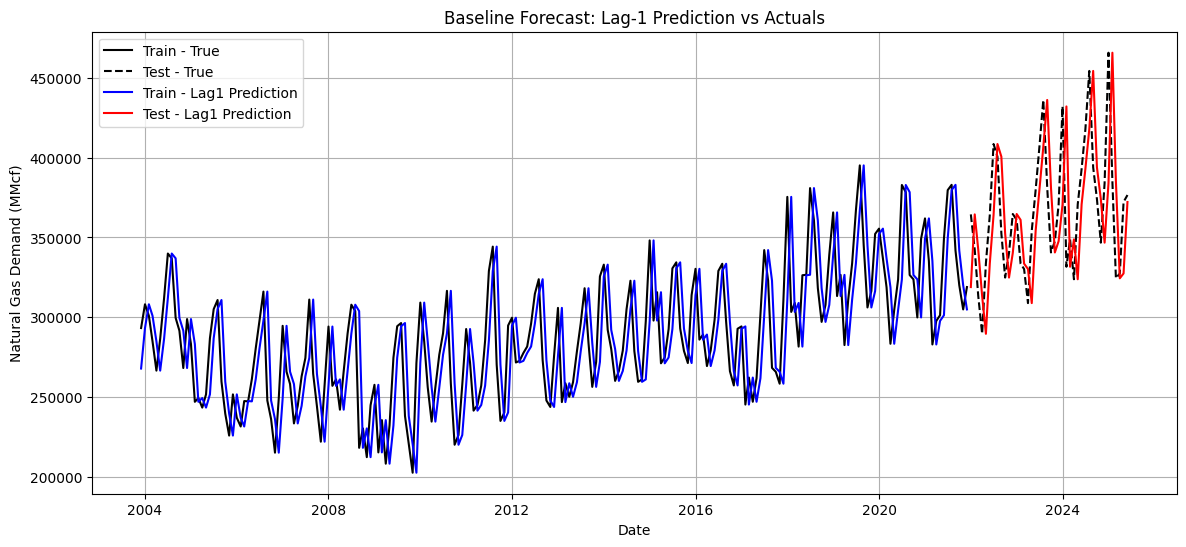

In [17]:
# Plot true vs predicted (lag values)
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

# True values
plt.plot(train2.index, train2["target"], label="Train - True", color="black")
plt.plot(test2.index,  test2["target"], label="Test - True", color="black", linestyle="--")

# Lag-based predictions
plt.plot(train2.index, train2["pred_lag1"], label="Train - Lag1 Prediction", color="blue")
plt.plot(test2.index,  test2["pred_lag1"], label="Test - Lag1 Prediction", color="red")

plt.title("Baseline Forecast: Lag-1 Prediction vs Actuals")
plt.xlabel("Date")
plt.ylabel("Natural Gas Demand (MMcf)")
plt.legend()
plt.grid(True)
plt.show()


In [18]:
# Computing baseline metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test2["target"], test2["pred_lag1"]))
mae  = mean_absolute_error(test2["target"], test2["pred_lag1"])

rmse, mae


(40292.90561152233, 33989.19047619047)